In [3]:
from neuromodes.io import fetch_surf
from neuromodes import EigenSolver

surf, medmask = fetch_surf()

# test plotting method
solver = EigenSolver(surf, mask=medmask).solve(10)

vb_lighting = {
    "ambient": 0.01,
    "diffuse": 1,
    "specular": 0.1,
    "roughness": 1e-6,
    "fresnel": 0
}

In [ ]:
# Lighting playground for solver.plot
import numpy as np

# Plotly Mesh3d defaults in plotly.js are approximately:
PLOTLY_DEFAULT_LIGHTING = {
    "ambient": 0.8,
    "diffuse": 0.8,
    "specular": 0.05,
    "roughness": 0.5,
    "fresnel": 0.2,
}

def show_lighting(
    lighting=None,
    flatshading=False,
    lightposition=(100, 200, 0),
    title=None,
    data_vec=None,
):
    """Render one figure with chosen lighting settings."""
    if data_vec is None:
        data_vec = solver.emodes[:, -1]

    fig = solver.plot(
        data=data_vec,
        lighting=lighting,
        flatshading=flatshading,
        lightposition=lightposition,
    )
    if title is not None:
        fig.update_layout(title=title)
    fig.show()

# 1) Compare defaults vs your current all-ones setup
show_lighting(
    lighting=PLOTLY_DEFAULT_LIGHTING,
    title="Plotly Mesh3d-like defaults",
)

show_lighting(
    lighting={"ambient": 1, "diffuse": 1, "specular": 1, "roughness": 1, "fresnel": 1},
    title="All ones (highly lit / washed in many cases)",
)

# 2) Quick sweep helper: vary one parameter while holding others fixed
def sweep_one_param(
    param_name,
    values,
    base=None,
    lightposition=(100, 200, 0),
    flatshading=False,
):
    if base is None:
        base = PLOTLY_DEFAULT_LIGHTING.copy()
    for v in values:
        lighting = base.copy()
        lighting[param_name] = float(v)
        show_lighting(
            lighting=lighting,
            flatshading=flatshading,
            lightposition=lightposition,
            title=f"{param_name}={v:.2f} | {lighting}",
        )

# Example sweeps (run one at a time):
sweep_one_param("ambient", np.linspace(0.2, 1.0, 5))
# sweep_one_param("diffuse", np.linspace(0.2, 1.2, 6))
# sweep_one_param("specular", np.linspace(0.0, 1.0, 6))
# sweep_one_param("roughness", np.linspace(0.0, 1.0, 6))
# sweep_one_param("fresnel", np.linspace(0.0, 1.0, 6))

# 3) Light position test (same lighting, different direction)
base = PLOTLY_DEFAULT_LIGHTING.copy()
for lp in [(0, 0, 200), (100, 200, 0), (300, 0, 50), (-200, -100, 300)]:
    show_lighting(
        lighting=base,
        lightposition=lp,
        title=f"lightposition={lp}",
    )

In [ ]:
# save fig to png
fig.write_image('test_plot.png')

In [ ]:
# new plot

fig = solver.plot(data=solver.emodes[:, -1], lighting=vb_lighting, lightposition=(-2, 0, 0))
fig.show()

In [ ]:
fig.write_image('test_plot_vb.png')

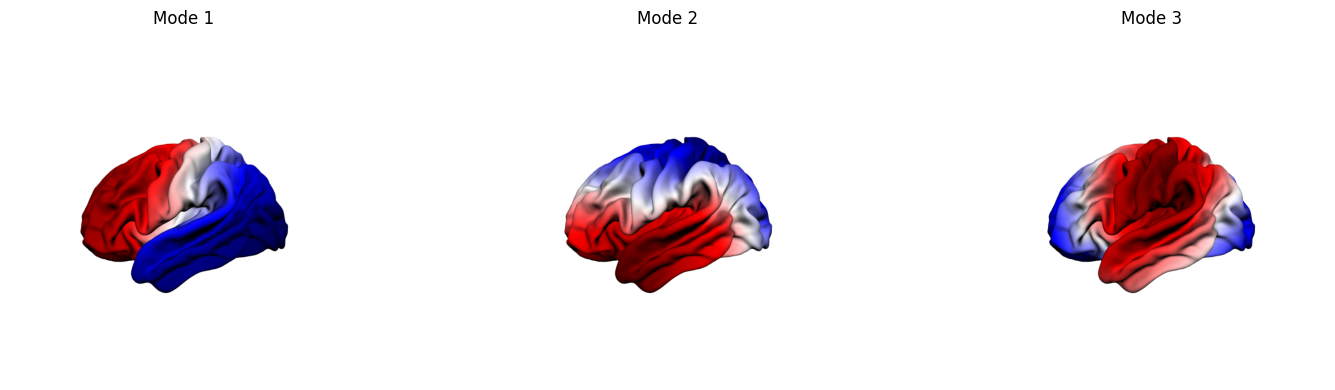

In [4]:
# Try plotting multiple modes on matplotlib axes
import matplotlib.pyplot as plt
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
solver.plot(data=solver.emodes[:, 1:4], axs=axs, lighting=vb_lighting, lightposition=(-2, 0, 0), labels=[f"Mode {i}" for i in range(1, 4)])
plt.tight_layout()
plt.show()

In [ ]:
# Save plot to png
fig.savefig('test_plot_multi.png')